## Benzene GNN Training

In [1]:
import numpy as np

import torch
import torch.nn.functional as F
from torch.nn import Linear, ModuleList
from torch_geometric.nn import GCNConv, GATConv, GINConv, global_add_pool
from torch_geometric.nn.models import MLP
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### 1. Load the Dataset


In [2]:
def load_graphs(datapath: str):
    data = np.load(datapath, allow_pickle = True)
    att, X, y = data['attr'], data['X'], data['y']
    ylist = [y[i][0] for i in range(y.shape[0])]

    X = X[0]

    all_graphs = []

    for i in range(len(X)):
        x = torch.from_numpy(X[i]['nodes'])
        edge_attr = torch.from_numpy(X[i]['edges'])
        y = torch.tensor([int(ylist[i])], dtype = torch.long)

        e1 = torch.from_numpy(X[i]['receivers']).long()
        e2 = torch.from_numpy(X[i]['senders']).long()

        edge_index = torch.stack([e1, e2])

        data_i = Data(
            x = x,
            y = y,
            edge_attr = edge_attr,
            edge_index = edge_index
        )

        all_graphs.append(data_i) # Add to larger list
        node_imp = torch.from_numpy(att[i][0]['nodes']).float()

        # Error-check:
        assert att[i][0]['n_edge'] == X[i]['n_edge'], 'Num: {}, Edges different sizes'.format(i)
        assert node_imp.shape[0] == x.shape[0], 'Num: {}, Shapes: {} vs. {}'.format(i, node_imp.shape[0], x.shape[0]) \
            + '\nExp: {} \nReal:{}'.format(att[i][0], X[i])

    return all_graphs

In [5]:
print("Loading local dataset files...")

def get_loaders(path):
    data_list = load_graphs(path)

    torch.manual_seed(1)
    test_size = int(0.10 * len(data_list))
    val_size = int(0.10 * len(data_list))
    train_size = len(data_list)-test_size-val_size

    train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(data_list, [train_size, test_size, val_size])

    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    in_channels = data_list[0].num_node_features
    num_classes = 2

    print(f"Total graphs: {len(data_list)}")
    print(f"Training graphs: {len(train_dataset)}")
    print(f"Testing graphs: {len(test_dataset)}")
    print(f"Validation graphs: {len(val_dataset)}")
    print(f"Node Features Dimension (in_channels): {in_channels}")
    print(f"Classes: {num_classes}")


    return train_loader, test_loader, val_loader, in_channels, num_classes

Loading local dataset files...



### 2. Define the Networks (GCN, GAT, GIN)

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GCN, self).__init__()
        
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.dropout = dropout
        self.num_layers = num_layers

        self.convs = ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels, node_bias=True))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = F.relu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = global_add_pool(x, batch)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)
        
        return x


class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GAT, self).__init__()
        
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.dropout = dropout
        self.num_layers = num_layers
        
        self.convs = torch.nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(GATConv(hidden_channels, hidden_channels))
            
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = F.elu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = global_add_pool(x, batch)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)
        
        return x


class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GIN, self).__init__()
        
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.dropout = dropout
        self.num_layers = num_layers

        self.convs = torch.nn.ModuleList()
        for i in range(num_layers):
            input_dim = in_channels if i == 0 else hidden_channels
            self.convs.append(
                GINConv(MLP([input_dim, 32, hidden_channels], dropout=self.dropout))
            )
            
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = F.relu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = global_add_pool(x, batch)

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)
        
        return x


### 3. Training Loop

In [8]:
def train(loader, graph_model, optimizer, criterion):
    graph_model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = graph_model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
        
    return total_loss / len(loader.dataset)

@torch.no_grad()
def test(loader, graph_model, criterion):
    graph_model.eval()
    correct = 0
    total_loss = 0
    for data in loader:
        data = data.to(device)
    
        out = graph_model(data.x, data.edge_index, data.batch)    
        batch_loss = criterion(out, data.y).item()
        total_loss += batch_loss * data.num_graphs 
        
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        
    return (
        correct / len(loader.dataset),
        total_loss / len(loader.dataset)
    )

In [9]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float("inf")

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss >= (self.min_validation_loss * (1 + self.min_delta)):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

## Execute Training

In [10]:
def full_training(model, model_name, train_loader, val_loader, test_loader):
    epochs = 500
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = (
        torch.nn.CrossEntropyLoss() if model.out_channels > 1 else torch.nn.BCELoss()
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=50, min_lr=1e-5, threshold=1e-3
    )
    early_stopper = EarlyStopper(patience=100)
    torch.manual_seed(1234)
    best_val_acc = 0

    history = {'train_loss':[], 'test_acc':[], 'best_val_acc':0}

    for epoch in range(epochs):
        train_loss = train(train_loader, model, optimizer, criterion)
        model.eval()
        val_acc, val_loss = test(loader=val_loader, graph_model=model, criterion=criterion)
        test_acc, test_loss = test(loader=test_loader, graph_model=model, criterion=criterion)
        scheduler.step(val_loss)
        print(
            f"\nEpoch: {epoch}"
            f"\nTrain Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Test Loss: {test_loss:.4f}"
            f"\nVal Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}"
        )
        history["train_loss"].append(train_loss)
        history["test_acc"].append(test_acc)

        if epoch == 1 or val_acc >= best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"./models/best_{model_name}")
            print(
                f"Best model saved at epoch {epoch}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}"
            )


        if early_stopper.early_stop(val_loss):
            print(f"Early stopping at epoch {epoch}")
            break
    
    history['best_val_acc'] = best_val_acc
    print("Training Complete!")
    return history

## GCN

In [14]:
gcn_history = {}

train_loader, test_loader, val_loader, in_channels, num_classes = get_loaders('benzene_data/benzene.npz')

hidden_channels = [64, 64, 128, 32]
for i in range(4):
    print(f"\nStarting GCN Training for {i+1} Layer Model...")
    gcn_model = GCN(
        in_channels=in_channels, 
        hidden_channels=hidden_channels[i], 
        out_channels=num_classes,
        num_layers=i+1,
        dropout=0.5
    ).to(device)
    history = full_training(gcn_model, f'gcn_{i+1}_layered_benzene', train_loader, val_loader, test_loader)
    gcn_history[str(i)] = history

Total graphs: 12000
Training graphs: 9600
Testing graphs: 1200
Validation graphs: 1200
Node Features Dimension (in_channels): 14
Classes: 2

Starting GCN Training for 1 Layer Model...

Epoch: 0
Train Loss: 0.6175, Val Loss: 0.5119, Test Loss: 0.5301
Val Acc: 0.7825, Test Acc: 0.7733
Best model saved at epoch 0, Val Acc: 0.7825, Test Acc: 0.7733

Epoch: 1
Train Loss: 0.5433, Val Loss: 0.5205, Test Loss: 0.5442
Val Acc: 0.7400, Test Acc: 0.7433
Best model saved at epoch 1, Val Acc: 0.7400, Test Acc: 0.7433

Epoch: 2
Train Loss: 0.5342, Val Loss: 0.4823, Test Loss: 0.4996
Val Acc: 0.7925, Test Acc: 0.7867
Best model saved at epoch 2, Val Acc: 0.7925, Test Acc: 0.7867

Epoch: 3
Train Loss: 0.5264, Val Loss: 0.4816, Test Loss: 0.5040
Val Acc: 0.7850, Test Acc: 0.7875


KeyboardInterrupt: 

## GAT

In [ ]:
gat_history = {}

train_loader, test_loader, val_loader, in_channels, num_classes = get_loaders('benzene_data/benzene.npz')

hidden_channels = [128, 128, 64, 128]
for i in range(4):
    print(f"\nStarting GAT Training for {i+1} Layer Model...")
    gat_model = GAT(
        in_channels=in_channels, 
        hidden_channels=hidden_channels[i], 
        out_channels=num_classes,
        num_layers=i+1,
        dropout=0.5
    ).to(device)
    history = full_training(gat_model, f'gat_{i+1}_layered_benzene', train_loader, val_loader, test_loader)
    gat_history[str(i)] = history

Total graphs: 12000
Training graphs: 9600
Testing graphs: 1200
Validation graphs: 1200
Node Features Dimension (in_channels): 14
Classes: 2

Starting GAT Training for 1 Layer Model...

Epoch: 0
Train Loss: 0.5897, Val Loss: 0.5390, Test Loss: 0.5552
Val Acc: 0.7600, Test Acc: 0.7525
Best model saved at epoch 0, Val Acc: 0.7600, Test Acc: 0.7525

Epoch: 1
Train Loss: 0.5398, Val Loss: 0.5164, Test Loss: 0.5317
Val Acc: 0.7692, Test Acc: 0.7667
Best model saved at epoch 1, Val Acc: 0.7692, Test Acc: 0.7667

Epoch: 2
Train Loss: 0.5276, Val Loss: 0.5128, Test Loss: 0.5337
Val Acc: 0.7742, Test Acc: 0.7617
Best model saved at epoch 2, Val Acc: 0.7742, Test Acc: 0.7617

Epoch: 3
Train Loss: 0.5245, Val Loss: 0.5086, Test Loss: 0.5346
Val Acc: 0.7583, Test Acc: 0.7658

Epoch: 4
Train Loss: 0.5278, Val Loss: 0.5034, Test Loss: 0.5340
Val Acc: 0.7650, Test Acc: 0.7558

Epoch: 5
Train Loss: 0.5167, Val Loss: 0.5030, Test Loss: 0.5365
Val Acc: 0.7675, Test Acc: 0.7667

Epoch: 6
Train Loss: 0.511

## GIN

In [ ]:
gin_history = {}

train_loader, test_loader, val_loader, in_channels, num_classes = get_loaders('benzene_data/benzene.npz')

hidden_channels = [16, 128, 128, 64]
for i in range(4):
    print(f"\nStarting GIN Training for {i+1} Layer Model...")
    gin_model = GIN(
        in_channels=in_channels, 
        hidden_channels=hidden_channels[i], 
        out_channels=num_classes,
        num_layers=i+1,
        dropout=0.5
    ).to(device)
    history = full_training(gin_model, f'gin_{i+1}_layered_benzene', train_loader, val_loader, test_loader)
    gin_history[str(i)] = history

Total graphs: 12000
Training graphs: 9600
Testing graphs: 1200
Validation graphs: 1200
Node Features Dimension (in_channels): 14
Classes: 2

Starting GIN Training for 1 Layer Model...

Epoch: 0
Train Loss: 0.6426, Val Loss: 0.5428, Test Loss: 0.5699
Val Acc: 0.7167, Test Acc: 0.6967
Best model saved at epoch 0, Val Acc: 0.7167, Test Acc: 0.6967

Epoch: 1
Train Loss: 0.5428, Val Loss: 0.4675, Test Loss: 0.4891
Val Acc: 0.8033, Test Acc: 0.7983
Best model saved at epoch 1, Val Acc: 0.8033, Test Acc: 0.7983

Epoch: 2
Train Loss: 0.5286, Val Loss: 0.5454, Test Loss: 0.5500
Val Acc: 0.6933, Test Acc: 0.6817

Epoch: 3
Train Loss: 0.5194, Val Loss: 0.4367, Test Loss: 0.4512
Val Acc: 0.8208, Test Acc: 0.8142
Best model saved at epoch 3, Val Acc: 0.8208, Test Acc: 0.8142

Epoch: 4
Train Loss: 0.5167, Val Loss: 0.4354, Test Loss: 0.4555
Val Acc: 0.8192, Test Acc: 0.8125

Epoch: 5
Train Loss: 0.5017, Val Loss: 0.4204, Test Loss: 0.4436
Val Acc: 0.8225, Test Acc: 0.8200
Best model saved at epoch 5

In [ ]:
import matplotlib.pyplot as plt


def smoothing(data, window_size):
    weights = np.ones(window_size) / window_size
    return np.convolve(data, weights, mode='valid')


def plot_history(history, model_name):
    colors = ['orange', 'red', 'purple', 'blue']

    plt.figure(figsize=(8,4))
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Training Loss {model_name}')
    for i in range(len(history.keys())):
        smoothed_train = smoothing(history[str(i)]['train_loss'], 5)
        plt.plot(smoothed_train, color=colors[i], label=f'{i}-layered')
    plt.grid()
    plt.legend(loc='best')
    plt.tight_layout()

    plt.figure(figsize=(10,5))
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Test Accuracy {model_name}')
    for i in range(len(history.keys())):
        smoothed_test = smoothing(history[str(i)]['test_acc'], 15)
        plt.plot(smoothed_test, color=colors[i], label=f'{i}-layered')
        plt.axhline(y=history[str(i)]['best_val_acc'], color=colors[i], linestyle='--', linewidth=0.5, label=f'Best saved {i}-layered model: acc={history[str(i)]['best_val_acc']:.2f}')
    plt.grid()
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

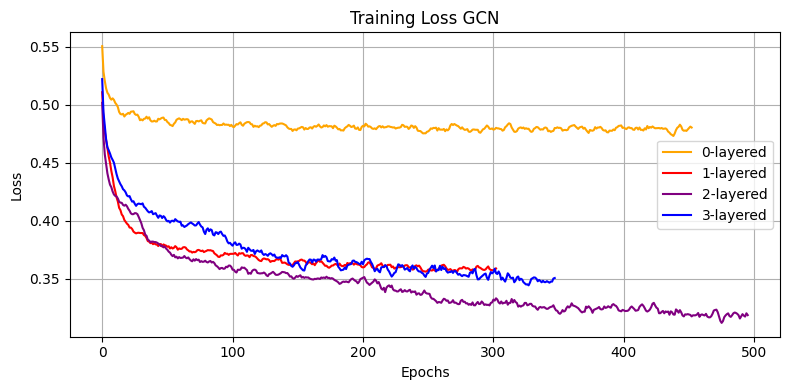

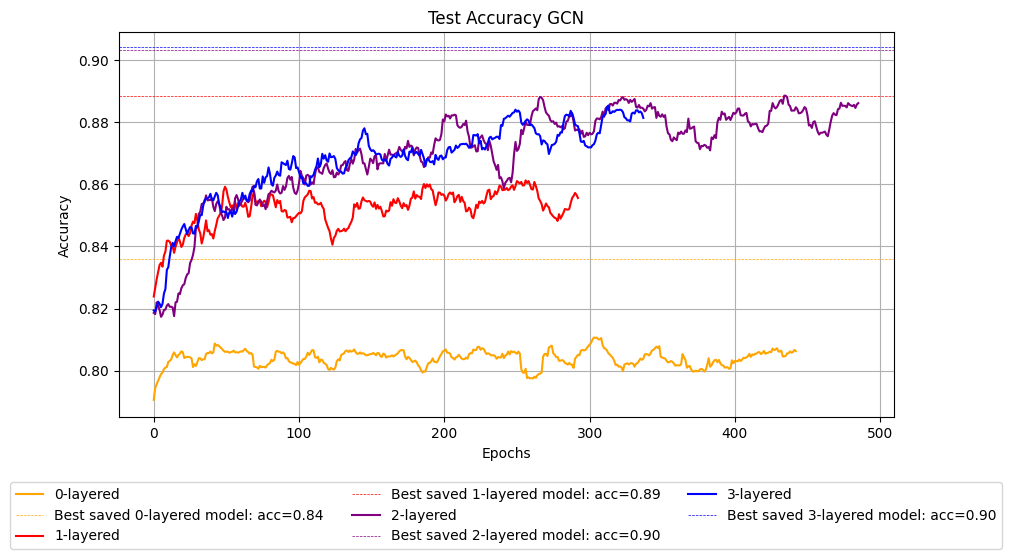

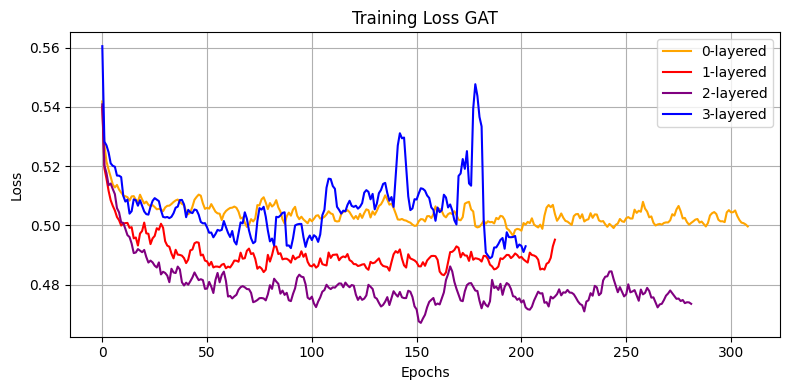

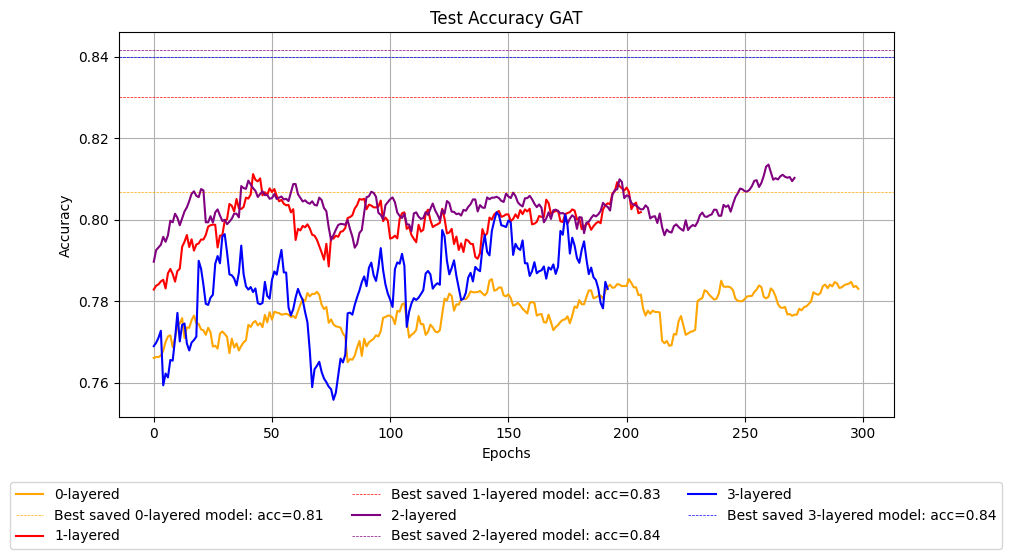

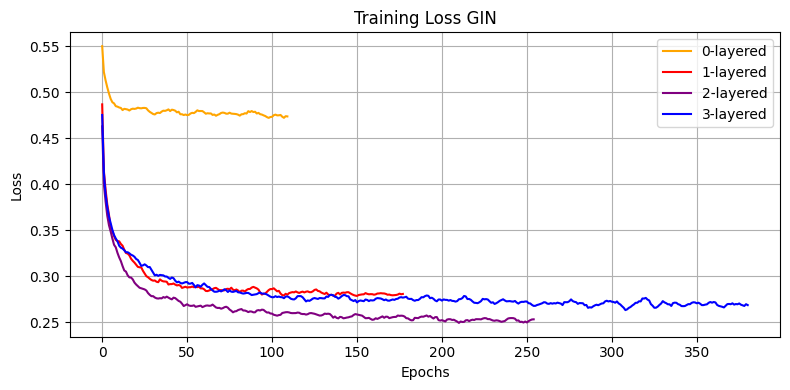

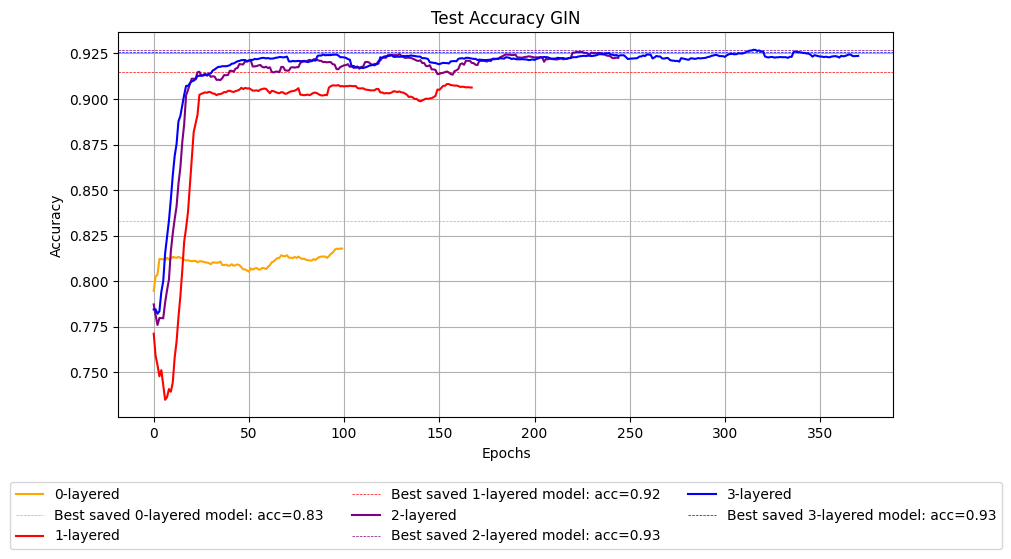

In [ ]:
plot_history(gcn_history, 'GCN')
plot_history(gat_history, 'GAT')
plot_history(gin_history, 'GIN')

In [12]:
import os

from tqdm import tqdm

import pandas as pd
from shapiq.graph import GraphGame, GraphSHAPIQ

def dummy_model(x, edge_index, batch):
    # return 20 dummy classes
    return torch.zeros((x.shape[0], 20))

def dummy_eval():
    return None

def evaluate_complexity(
    dataset_name, n_layers, all_samples_to_explain, masking_mode="feature-removal"
):
    gshap_budget = {}
    gshap_budget_est = {}
    players = {}
    max_neighborhood_size = {}

    for data_id, x_graph in enumerate(tqdm(all_samples_to_explain, desc='Evaluating Samples...')):
        dummy_module = torch.nn.Module()
        dummy_module.forward = dummy_model
        dummy_module.eval = dummy_eval
        game = GraphGame(
            dummy_module,
            x_graph=x_graph,
            class_id=x_graph.y.item(),
            max_neighborhood_size=n_layers,
            masking_mode=masking_mode,
            normalize=False,
            baseline=0,
        )
        gSHAP = GraphSHAPIQ(game)

        gshap_budget[data_id] = gSHAP.total_budget
        players[data_id] = gSHAP.n_players
        max_neighborhood_size[data_id] = gSHAP.max_neighborhood_size
        gshap_budget_est[data_id] = gSHAP.budget_estimated

    results = pd.DataFrame(
        index=gshap_budget.keys(), data=gshap_budget.values(), columns=["budget"]
    )
    results["budget_upper_bound"] = gshap_budget_est
    results["max_neighborhood_size"] = max_neighborhood_size
    results["n_players"] = players

    save_name = "_".join(["complexity", dataset_name + "_" + str(n_layers)])
    save_path = os.path.join("../results/complexity_analysis", save_name + ".csv")
    results.to_csv(save_path)


all_graphs = load_graphs("benzene_data/benzene.npz")
loader = DataLoader(all_graphs, batch_size=64, shuffle=False)
all_samples_to_explain = []
for data in train_loader:
    for i in range(data.num_graphs):
        all_samples_to_explain.append(data[i])
evaluate_complexity('Benzene', 1, all_samples_to_explain)

ModuleNotFoundError: No module named 'shapiq'

In [15]:
%load_ext autoreload
%autoreload 2

import os
print(os.getcwd())

from shapiq import ExactComputer

from shapiq.graph import GraphGame, GraphSHAPIQ

def run_ablation(deep_model, data_point) -> tuple[float, float]:
    # make it a game -------------------------------------------------------------------------------
    output = deep_model(data_point.x, data_point.edge_index, data_point.batch).squeeze(dim=0).detach().numpy()
    predicted_class = int(np.argmax(output, axis=0))
    game = GraphGame(
        model=deep_model,
        x_graph=data_point,
        class_index=predicted_class,
        baseline_strategy='average'
    )

    # compute values with GraphSHAPIQ --------------------------------------------------------------
    print("Computing GraphSHAPIQ values...")
    explainer = GraphSHAPIQ(game)
    if explainer.total_budget > 20_000:
        # skip
        print(f"Skipping due to high budget {explainer.total_budget}")
        return 0.0, 0.0
    explainer_values, _ = explainer.explain(order=game.n_players)

    # compute the exact game -----------------------------------------------------------------------
    print("Computing exact values...")
    computer = ExactComputer(game.n_players, game)
    exact_values = computer(index="Moebius", order=game.n_players)

    # compare the results --------------------------------------------------------------------------
    differences = exact_values - explainer_values
    differences_sum = sum(np.abs(differences.values))
    print("Exact values:", exact_values)
    print("GraphSHAPIQ values:", explainer_values)
    print("Difference:", differences)
    print("Sum of diff:", differences_sum)

    diff_manual = 0.0
    for interaction in exact_values.interaction_lookup.keys():
        diff_manual += np.abs(exact_values[interaction] - explainer_values[interaction])
    for interaction in explainer_values.interaction_lookup.keys():
        if interaction not in exact_values.interaction_lookup:
            diff_manual += np.abs(exact_values[interaction] - explainer_values[interaction])
    print("Sum of diff (manual):", diff_manual)

    return differences_sum, diff_manual


if __name__ == "__main__":

    # model parameters -----------------------------------------------------------------------------
    DATASET_NAME = "PROTEINS"
    MODEL_TYPE = "GIN"
    N_LAYER = 1

    # run parameters -------------------------------------------------------------------------------
    N_RUNS = 15
    MAX_NODES = 12

    # get the model --------------------------------------------------------------------------------
    hidden_channels = [64, 64, 128, 32]
    print(f"\Loading GCN for 4 Layered Model...")
    model = GCN(in_channels=14, hidden_channels=64, out_channels=2, num_layers=1)

    # get the explanation instances ----------------------------------------------------------------
    all_graphs = load_graphs("benzene_data/benzene.npz")
    loader = DataLoader(all_graphs, batch_size=64, shuffle=False)
    explanation_instances = []
    for data in loader:
        for i in range(data.num_graphs):
            explanation_instances.append(data[i])
    # select only instances with less than MAX_NODES nodes
    small_nodes = []
    for graph in explanation_instances:
        if graph.num_nodes <= MAX_NODES:
            small_nodes.append(graph)
    print(f"Number of instances with less than {MAX_NODES} nodes:", len(small_nodes))

    diffs, diffs_manual = 0, 0
    for i in range(N_RUNS):
        print(f"Run {i+1}/{N_RUNS}")
        diff = run_ablation(model, small_nodes[i])
        diffs += diff[0]
        diffs_manual += diff[1]
        print("\n")

    print(f"Average difference: {diffs/N_RUNS}")
    print(f"Average difference (manual): {diffs_manual/N_RUNS}")


<>:68: SyntaxWarning: invalid escape sequence '\L'
<>:68: SyntaxWarning: invalid escape sequence '\L'
/var/folders/q2/jbq21gwx0lx_cndh6l_s1zjm0000gn/T/ipykernel_58359/2619174899.py:68: SyntaxWarning: invalid escape sequence '\L'
  print(f"\Loading GCN for 4 Layered Model...")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/finn.krammer/Documents/shapiq-fork/shapiq/src/shapiq/graph/demo
\Loading GCN for 4 Layered Model...
Number of instances with less than 12 nodes: 653
Run 1/15


/var/folders/q2/jbq21gwx0lx_cndh6l_s1zjm0000gn/T/ipykernel_58359/2619174899.py:68: SyntaxWarning: invalid escape sequence '\L'
  print(f"\Loading GCN for 4 Layered Model...")


TypeError: Model must be GCN, GIN, or GAT, got 'GCN'.

In [ ]:
gcn_fc_history = {}

train_loader, test_loader, val_loader, in_channels, num_classes = get_loaders('fc_data/fluoride_carbonyl.npz')

hidden_channels = [16, 64, 32, 128]
for i in range(4):
    print(f"\nStarting GCN Training for {i+1} Layer Model...")
    gcn_model = GCN(
        in_channels=in_channels, 
        hidden_channels=hidden_channels[i], 
        out_channels=num_classes,
        num_layers=i+1,
        dropout=0.5
    ).to(device)
    history = full_training(gcn_model, f'gcn_{i+1}_layered_fc', train_loader, val_loader, test_loader)
    gcn_fc_history[str(i)] = history

Total graphs: 8671
Training graphs: 6937
Testing graphs: 867
Validation graphs: 867
Node Features Dimension (in_channels): 14
Classes: 2

Starting GCN Training for 1 Layer Model...

Epoch: 0
Train Loss: 0.4822, Val Loss: 0.4520, Test Loss: 0.4671
Val Acc: 0.8304, Test Acc: 0.8201
Best model saved at epoch 0, Val Acc: 0.8304, Test Acc: 0.8201

Epoch: 1
Train Loss: 0.4659, Val Loss: 0.4479, Test Loss: 0.4618
Val Acc: 0.8304, Test Acc: 0.8201
Best model saved at epoch 1, Val Acc: 0.8304, Test Acc: 0.8201

Epoch: 2
Train Loss: 0.4610, Val Loss: 0.4446, Test Loss: 0.4595
Val Acc: 0.8304, Test Acc: 0.8201
Best model saved at epoch 2, Val Acc: 0.8304, Test Acc: 0.8201

Epoch: 3
Train Loss: 0.4615, Val Loss: 0.4482, Test Loss: 0.4626
Val Acc: 0.8304, Test Acc: 0.8201
Best model saved at epoch 3, Val Acc: 0.8304, Test Acc: 0.8201

Epoch: 4
Train Loss: 0.4608, Val Loss: 0.4498, Test Loss: 0.4644
Val Acc: 0.8304, Test Acc: 0.8201
Best model saved at epoch 4, Val Acc: 0.8304, Test Acc: 0.8201

Epo

KeyboardInterrupt: 

In [ ]:
gat_fc_history = {}

train_loader, test_loader, val_loader, in_channels, num_classes = get_loaders('fc_data/fluoride_carbonyl.npz')

hidden_channels = [16, 16, 16, 128]
for i in range(4):
    print(f"\nStarting GAT Training for {i+1} Layer Model...")
    gat_model = GAT(
        in_channels=in_channels, 
        hidden_channels=hidden_channels[i], 
        out_channels=num_classes,
        num_layers=i+1,
        dropout=0.5
    ).to(device)
    history = full_training(gat_model, f'gat_{i+1}_layered_fc', train_loader, val_loader, test_loader)
    gat_fc_history[str(i)] = history

In [ ]:
gin_fc_history = {}

train_loader, test_loader, val_loader, in_channels, num_classes = get_loaders('fc_data/fluoride_carbonyl.npz')

hidden_channels = [64, 32, 32, 128]
for i in range(4):
    print(f"\nStarting GIN Training for {i+1} Layer Model...")
    gin_model = GIN(
        in_channels=in_channels, 
        hidden_channels=hidden_channels[i], 
        out_channels=num_classes,
        num_layers=i+1,
        dropout=0.5
    ).to(device)
    history = full_training(gin_model, f'gin_{i+1}_layered_fc', train_loader, val_loader, test_loader)
    gin_fc_history[str(i)] = history